<a href="https://colab.research.google.com/github/prakalya427-pixel/-AI-Internship-/blob/main/mnist_dataset_using_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [62]:
m=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=m.load_data()
x_train,x_test=x_train/255.0,x_test/255


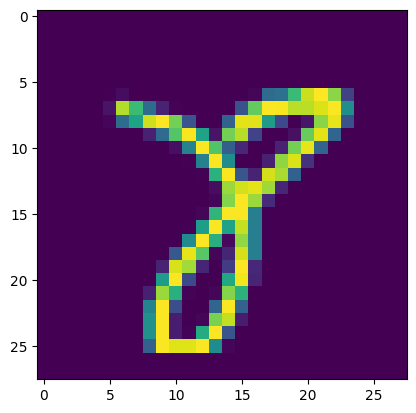

In [63]:
import matplotlib.pyplot as plt
plt.imshow(x_train[57737])

In [64]:
x_train.shape

(60000, 28, 28)

In [65]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [66]:
model.compile(
    optimizer ='adam',
    loss ='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [67]:
model.fit(x_train,y_train,validation_split=0.1,epochs=12)

Epoch 1/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9234 - loss: 0.2705 - val_accuracy: 0.9637 - val_loss: 0.1323
Epoch 2/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9635 - loss: 0.1234 - val_accuracy: 0.9728 - val_loss: 0.0950
Epoch 3/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9741 - loss: 0.0864 - val_accuracy: 0.9737 - val_loss: 0.0910
Epoch 4/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9803 - loss: 0.0642 - val_accuracy: 0.9727 - val_loss: 0.0879
Epoch 5/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9843 - loss: 0.0495 - val_accuracy: 0.9765 - val_loss: 0.0834
Epoch 6/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9882 - loss: 0.0380 - val_accuracy: 0.9748 - val_loss: 0.0892
Epoch 7/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9785 - val_loss: 0.0836
Epoch 8/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9926 - loss: 0.0252 - 

In [68]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [69]:
y_pred[4576]

array([1.4197951e-15, 1.6412166e-13, 1.3547512e-09, 1.8903705e-12,
       9.9999541e-01, 2.7136127e-11, 7.2910202e-12, 9.1864838e-10,
       2.0429485e-09, 4.5126458e-06], dtype=float32)

In [70]:
import numpy as np
y_pr=np.argmax(y_pred,axis=1)
print(y_pr[4576])

4


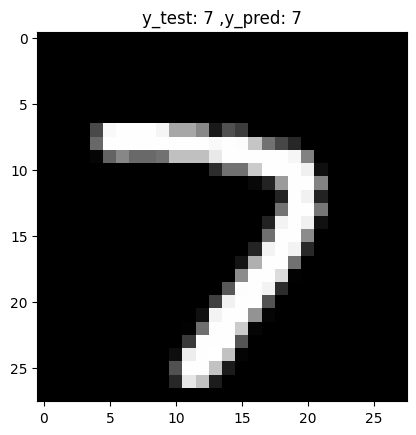

In [71]:
plt.imshow(x_test[17],cmap='gray')
true_label = y_test[1703]
predicted_label = np.argmax(y_pred[17])
plt.title(f"y_test: {true_label} ,y_pred: {predicted_label}")
plt.show()

In [72]:
import cv2

In [73]:
img=cv2.imread('/content/Handwrittern letter.jpeg',0)

In [74]:
img2=cv2.resize(img,(28,28))

In [75]:
#display image
from google.colab.patches import cv2_imshow
cv2_imshow(img2)

In [95]:
model.save('mnist_model.h5')